In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("medical_disease_prediction_10000.csv")
df

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,Male,17.5,102,177,161,88,No,No,Medium,No,Healthy
1,69,Male,31.1,118,256,147,92,No,No,High,Yes,Pre-Diabetes
2,61,Female,31.3,114,206,193,74,Yes,No,Medium,No,Healthy
3,47,Female,23.9,105,162,253,68,No,No,Low,No,Healthy
4,47,Male,28.3,148,121,280,84,No,Yes,High,No,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,49,Male,27.1,177,183,268,59,No,No,High,No,Hypertension
9996,84,Male,29.2,142,215,145,77,No,Yes,High,Yes,Hypertension
9997,41,Male,22.8,177,265,133,71,No,No,Medium,Yes,Hypertension
9998,55,Male,29.0,126,241,298,57,No,No,Medium,Yes,Pre-Diabetes


In [3]:
df.head()

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,Male,17.5,102,177,161,88,No,No,Medium,No,Healthy
1,69,Male,31.1,118,256,147,92,No,No,High,Yes,Pre-Diabetes
2,61,Female,31.3,114,206,193,74,Yes,No,Medium,No,Healthy
3,47,Female,23.9,105,162,253,68,No,No,Low,No,Healthy
4,47,Male,28.3,148,121,280,84,No,Yes,High,No,Healthy


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               10000 non-null  int64  
 1   Gender            10000 non-null  object 
 2   BMI               10000 non-null  float64
 3   BloodPressure     10000 non-null  int64  
 4   GlucoseLevel      10000 non-null  int64  
 5   Cholesterol       10000 non-null  int64  
 6   HeartRate         10000 non-null  int64  
 7   Smoking           10000 non-null  object 
 8   Alcohol           10000 non-null  object 
 9   PhysicalActivity  10000 non-null  object 
 10  FamilyHistory     10000 non-null  object 
 11  Disease           10000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 937.6+ KB


In [5]:
print(df.isnull().sum())



Age                 0
Gender              0
BMI                 0
BloodPressure       0
GlucoseLevel        0
Cholesterol         0
HeartRate           0
Smoking             0
Alcohol             0
PhysicalActivity    0
FamilyHistory       0
Disease             0
dtype: int64


In [6]:
print(df.duplicated().sum())

0


In [7]:
df['Disease'].unique()

array(['Healthy', 'Pre-Diabetes', 'Hypertension', 'Heart Disease',
       'Diabetes'], dtype=object)

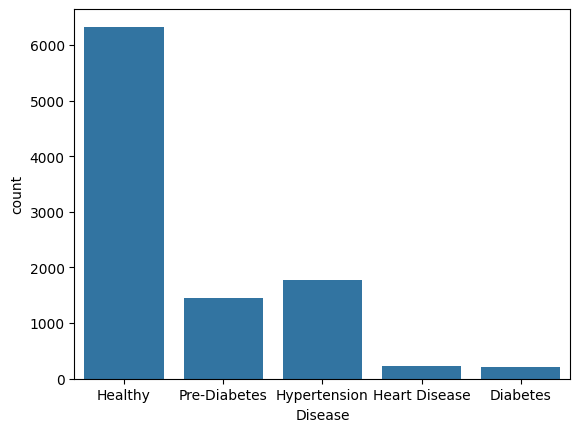

In [8]:
sns.countplot(x='Disease', data=df)
plt.show()

In [9]:
char=df.select_dtypes(include='object')
num=df.select_dtypes(exclude='object')
print(char)
print(num)

      Gender Smoking Alcohol PhysicalActivity FamilyHistory       Disease
0       Male      No      No           Medium            No       Healthy
1       Male      No      No             High           Yes  Pre-Diabetes
2     Female     Yes      No           Medium            No       Healthy
3     Female      No      No              Low            No       Healthy
4       Male      No     Yes             High            No       Healthy
...      ...     ...     ...              ...           ...           ...
9995    Male      No      No             High            No  Hypertension
9996    Male      No     Yes             High           Yes  Hypertension
9997    Male      No      No           Medium           Yes  Hypertension
9998    Male      No      No           Medium           Yes  Pre-Diabetes
9999    Male      No      No             High           Yes  Pre-Diabetes

[10000 rows x 6 columns]
      Age   BMI  BloodPressure  GlucoseLevel  Cholesterol  HeartRate
0      23  17.5  

In [10]:
smoking_dict={'No':0,'Yes':1}
char['Smoking']=char['Smoking'].map(smoking_dict)


In [11]:
alcohol_dict={'No':0,'Yes':1}
char['Alcohol']=char['Alcohol'].map(alcohol_dict)

In [12]:
fh_dict={'No':0,'Yes':1}
char['FamilyHistory']=char['FamilyHistory'].map(fh_dict)

In [13]:
disease_dict={'Healthy':1, 'Pre-Diabetes':2,'Diabetes':3, 'Hypertension':4, 'Heart Disease':5,}
char['Disease']=char['Disease'].map(disease_dict)

In [14]:
pa_dict={'Low':0,'Medium':1,'High':2}
char['PhysicalActivity']=char['PhysicalActivity'].map(pa_dict)

In [15]:
gender_dict={'Male':0,'Female':1}
char['Gender'] = char['Gender'].map(gender_dict)

In [16]:
char

,Gender,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,0,0,0,1,0,1
1,0,0,0,2,1,2
2,1,1,0,1,0,1
3,1,0,0,0,0,1
4,0,0,1,2,0,1
...,...,...,...,...,...,...
9995,0,0,0,2,0,4
9996,0,0,1,2,1,4
9997,0,0,0,1,1,4
9998,0,0,0,1,1,2


In [17]:
num

,Age,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate
0,23,17.5,102,177,161,88
1,69,31.1,118,256,147,92
2,61,31.3,114,206,193,74
3,47,23.9,105,162,253,68
4,47,28.3,148,121,280,84
...,...,...,...,...,...,...
9995,49,27.1,177,183,268,59
9996,84,29.2,142,215,145,77
9997,41,22.8,177,265,133,71
9998,55,29.0,126,241,298,57


In [18]:
df=pd.concat([num,char],axis=1)

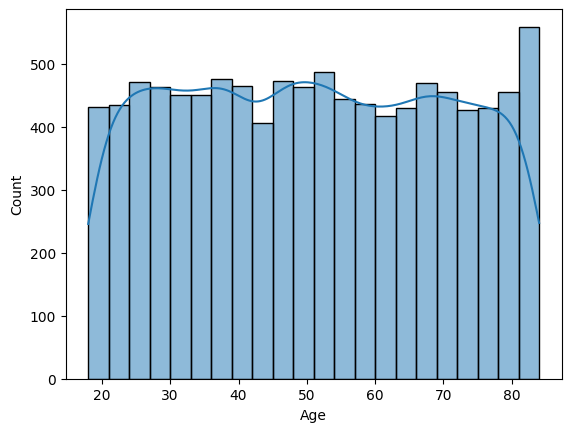

In [19]:
sns.histplot(df['Age'], kde=True)
plt.show()

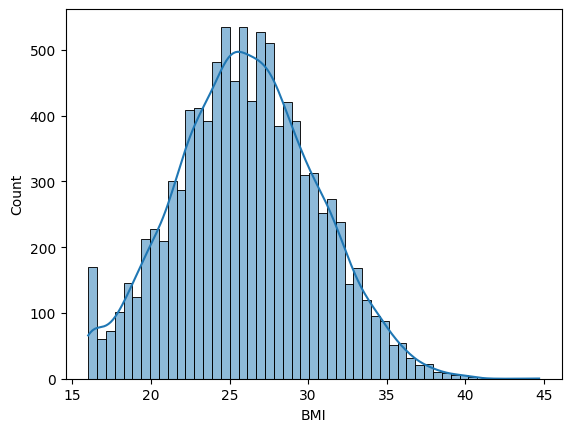

In [20]:
sns.histplot(df['BMI'], kde=True)
plt.show()

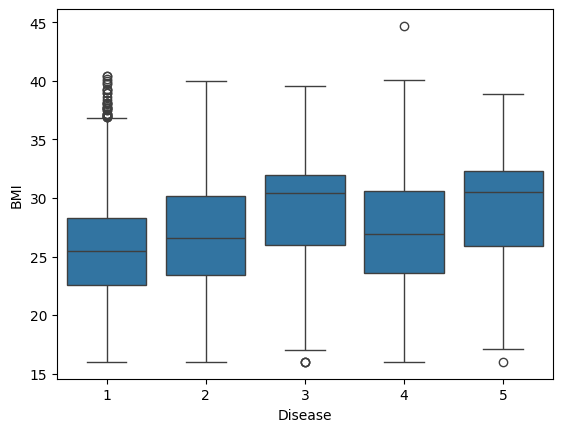

In [21]:
sns.boxplot(x='Disease', y='BMI', data=df)
plt.show()

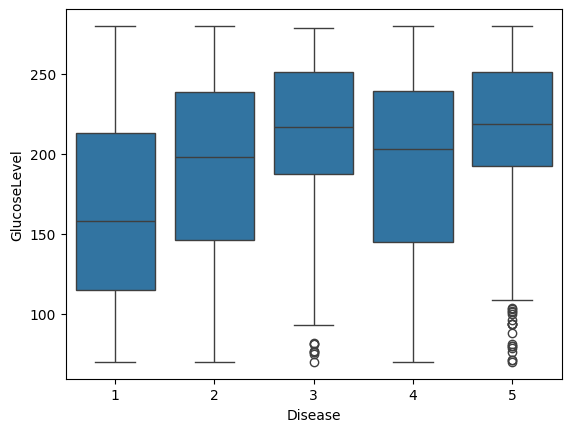

In [22]:
sns.boxplot(x='Disease', y='GlucoseLevel', data=df)
plt.show()

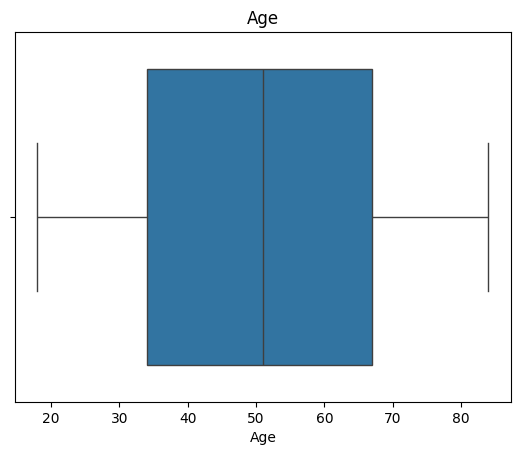

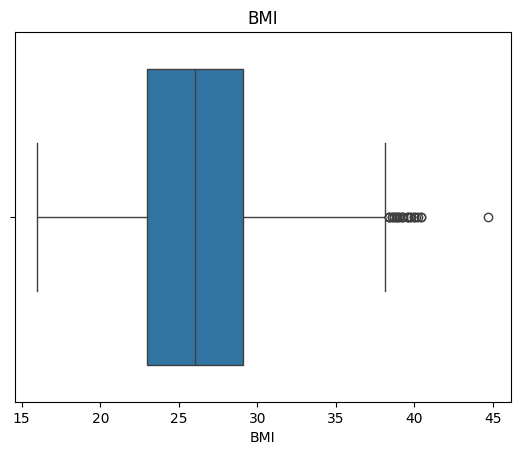

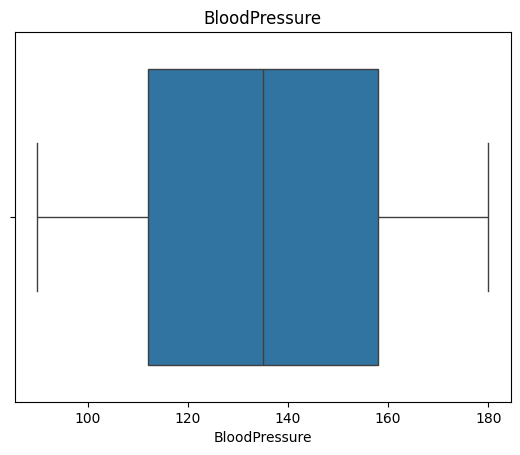

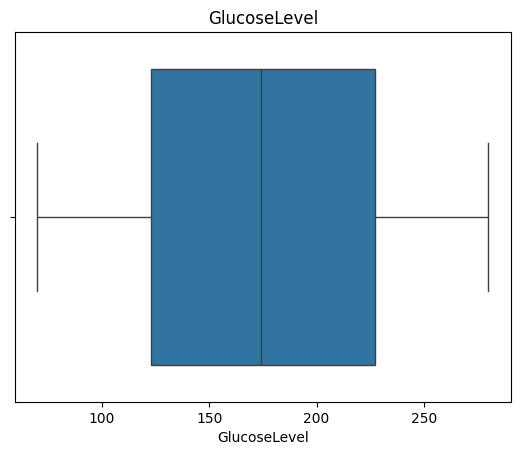

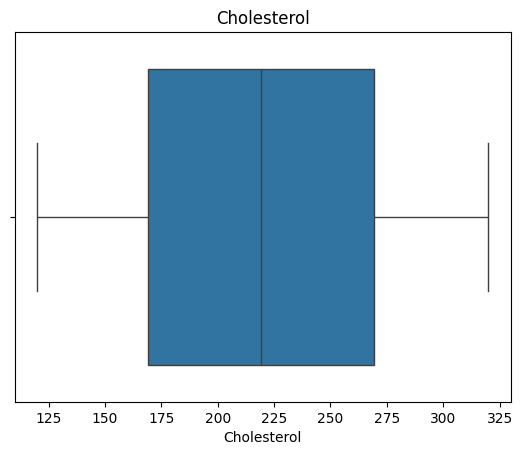

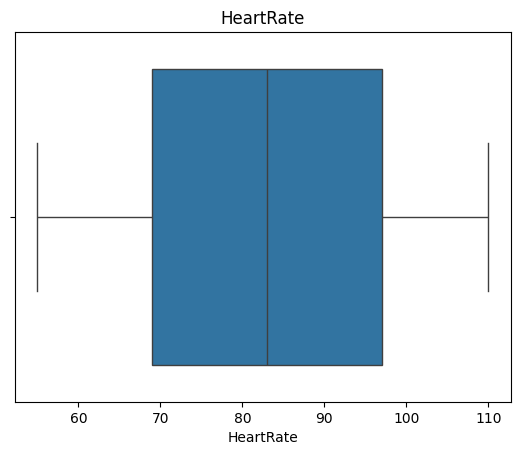

In [23]:
num_cols = ['Age',
            'BMI',
            'BloodPressure',
            'GlucoseLevel',
            'Cholesterol',
            'HeartRate']

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [24]:
x = df.drop('Disease', axis=1)

y = df['Disease']
print(x.shape)
print(y.shape)

(10000, 11)
(10000,)
